<a href="https://colab.research.google.com/github/vaidegiarch/project-4--airline-price/blob/main/aircraft_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from sklearn import metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import pickle

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Data_Train.xlsx to Data_Train.xlsx


In [3]:
import pandas as pd
df = pd.read_excel("Data_Train.xlsx")

In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.drop('Additional_Info', axis=1, inplace=True)#dropping column that has no effective values

In [7]:
df.drop('Route', axis=1, inplace=True)#dropping column

In [8]:
df.drop_duplicates(inplace=True)#checking and dropping duplicates

## converting data type

In [9]:
df['Date_of_Journey'] = pd.to_datetime((df['Date_of_Journey']),format='%d/%m/%Y')

In [10]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.strftime('%H:%M')


In [11]:
df['Dep_hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute

In [12]:
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'], format='mixed', errors='coerce')
df['Arrival_Time'] = df['Arrival_Time'].dt.strftime('%H:%M')

In [13]:
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.minute

In [14]:
df['Duration'] = df['Duration'].str.findall(r'\d+').apply(
    lambda x: int(x[0])*60 + int(x[1]) if len(x)==2 else int(x[0]) #converting hr/mins to total mins
)

In [15]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,170,non-stop,3897,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,445,2 stops,7662,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19,2 stops,13882,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,325,1 stop,6218,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,285,1 stop,13302,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,19:55,22:25,150,non-stop,4107,19,55,22,25
10679,Air India,2019-04-27,Kolkata,Banglore,20:45,23:20,155,non-stop,4145,20,45,23,20
10680,Jet Airways,2019-04-27,Banglore,Delhi,08:20,11:20,3,non-stop,7229,8,20,11,20
10681,Vistara,2019-03-01,Banglore,New Delhi,11:30,14:10,160,non-stop,12648,11,30,14,10


In [16]:
df.drop('Arrival_Time', axis=1, inplace=True)

In [17]:
df.drop('Dep_Time', axis=1, inplace=True)

In [18]:
df

,Airline,Date_of_Journey,Source,Destination,Duration,Total_Stops,Price,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,2019-03-24,Banglore,New Delhi,170,non-stop,3897,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,445,2 stops,7662,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,19,2 stops,13882,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,325,1 stop,6218,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,285,1 stop,13302,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,150,non-stop,4107,19,55,22,25
10679,Air India,2019-04-27,Kolkata,Banglore,155,non-stop,4145,20,45,23,20
10680,Jet Airways,2019-04-27,Banglore,Delhi,3,non-stop,7229,8,20,11,20
10681,Vistara,2019-03-01,Banglore,New Delhi,160,non-stop,12648,11,30,14,10


### EDA(Data visualization)

Target variable-Price -uni variant analysis

/tmp/ipykernel_160/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

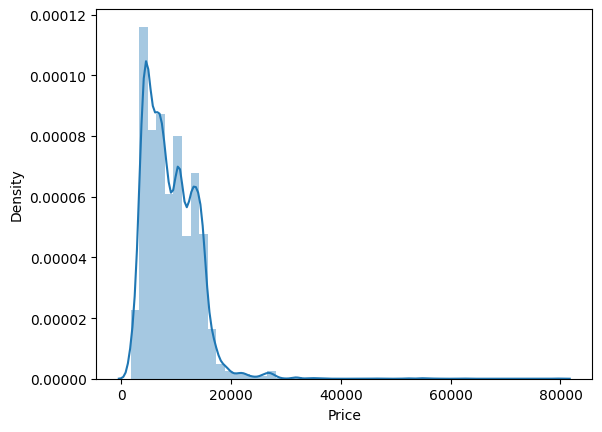

In [ ]:
sns.distplot(df['Price'])

insights- showing that most airline are priced under 20,000 with a long tail of infrequent high-value outliers extending toward 80,000.

### Categorical vs target -bivariant analysis

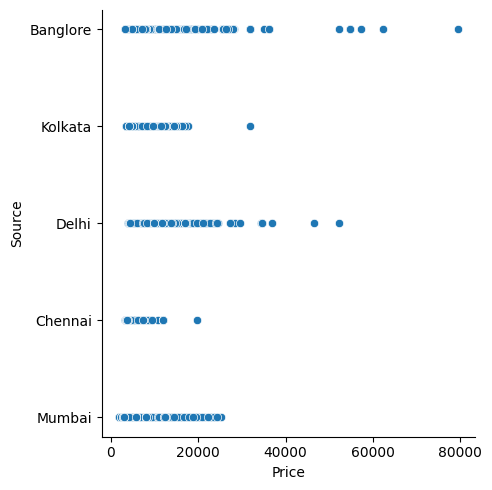

In [ ]:
sns.relplot(x="Price",y="Source",data=df)#city vs price

insights-Flights from **Bangalore and Delhi show the highest price** spread and peaks, while **Chennai and Mumbai mostly have lower**, tightly clustered fares.

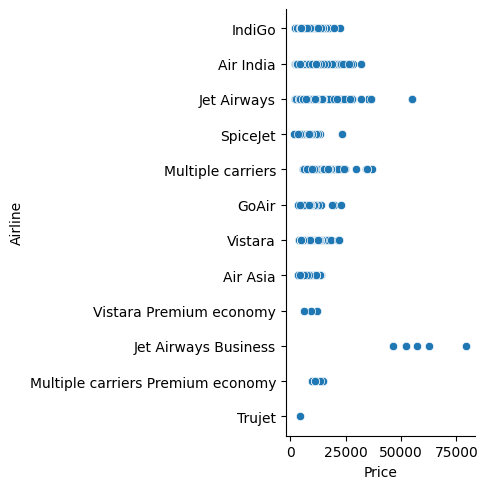

In [ ]:
sns.relplot(x="Price",y="Airline",data=df) #airline vs price

**Jet Airways Business and Vistara Premium Economy have the highest** fares, while most other airlines cluster in mid-to-low price ranges.

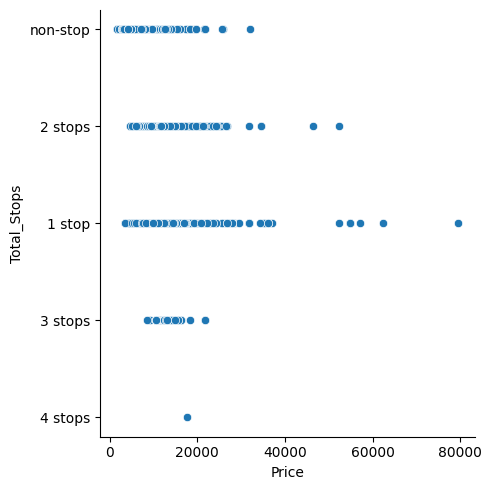

In [ ]:
sns.relplot(x="Price",y="Total_Stops",data=df)#stops vs price

insights-As the number of** stops increases,** the baseline price and price variance **typically rise**, with 1-stop flights showing the highest peak prices and non-stop flights remaining the most consistently affordable.

### Numerical vs target

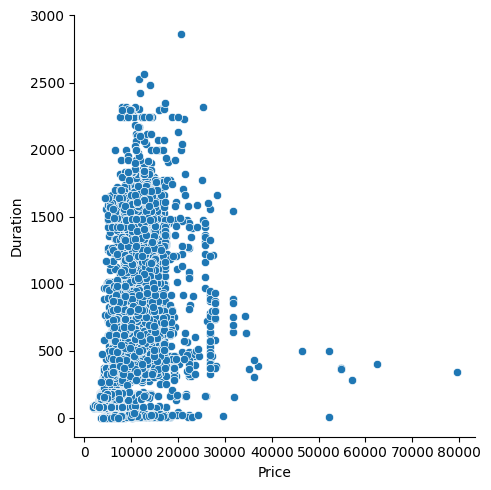

In [ ]:
sns.relplot(x="Price",y="Duration",data=df)

insights- While longer travel durations and more stops generally correlate with higher prices, the most expensive tickets often result from premium flight classes or last-minute bookings rather than just the time spent in the air or the number of layovers.

### Encoding

In [19]:
df['Total_Stops'] = df['Total_Stops'].map({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})#It’s categorical but has order (non-stop < 1 stop < 2 stops)#ordinal

In [20]:
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination'])#nominal

In [21]:
df

,Date_of_Journey,Duration,Total_Stops,Price,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,2019-03-24,170,0.0,3897,22,20,1,10,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2019-05-01,445,2.0,7662,5,50,13,15,False,True,...,False,False,True,False,True,False,False,False,False,False
2,2019-06-09,19,2.0,13882,9,25,4,25,False,False,...,False,True,False,False,False,True,False,False,False,False
3,2019-05-12,325,1.0,6218,18,5,23,30,False,False,...,False,False,True,False,True,False,False,False,False,False
4,2019-03-01,285,1.0,13302,16,50,21,35,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,2019-04-09,150,0.0,4107,19,55,22,25,True,False,...,False,False,True,False,True,False,False,False,False,False
10679,2019-04-27,155,0.0,4145,20,45,23,20,False,True,...,False,False,True,False,True,False,False,False,False,False
10680,2019-04-27,3,0.0,7229,8,20,11,20,False,False,...,False,False,False,False,False,False,True,False,False,False
10681,2019-03-01,160,0.0,12648,11,30,14,10,False,False,...,False,False,False,False,False,False,False,False,False,True


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Date_of_Journey                            10463 non-null  datetime64[ns]
 1   Duration                                   10463 non-null  int64         
 2   Total_Stops                                10462 non-null  float64       
 3   Price                                      10463 non-null  int64         
 4   Dep_hour                                   10463 non-null  int32         
 5   Dep_min                                    10463 non-null  int32         
 6   Arrival_hour                               10463 non-null  int32         
 7   Arrival_min                                10463 non-null  int32         
 8   Airline_Air Asia                           10463 non-null  bool          
 9   Airline_Air India     

## Feature Selection-Finding out the best feature which will contribute and have good relation with target variable

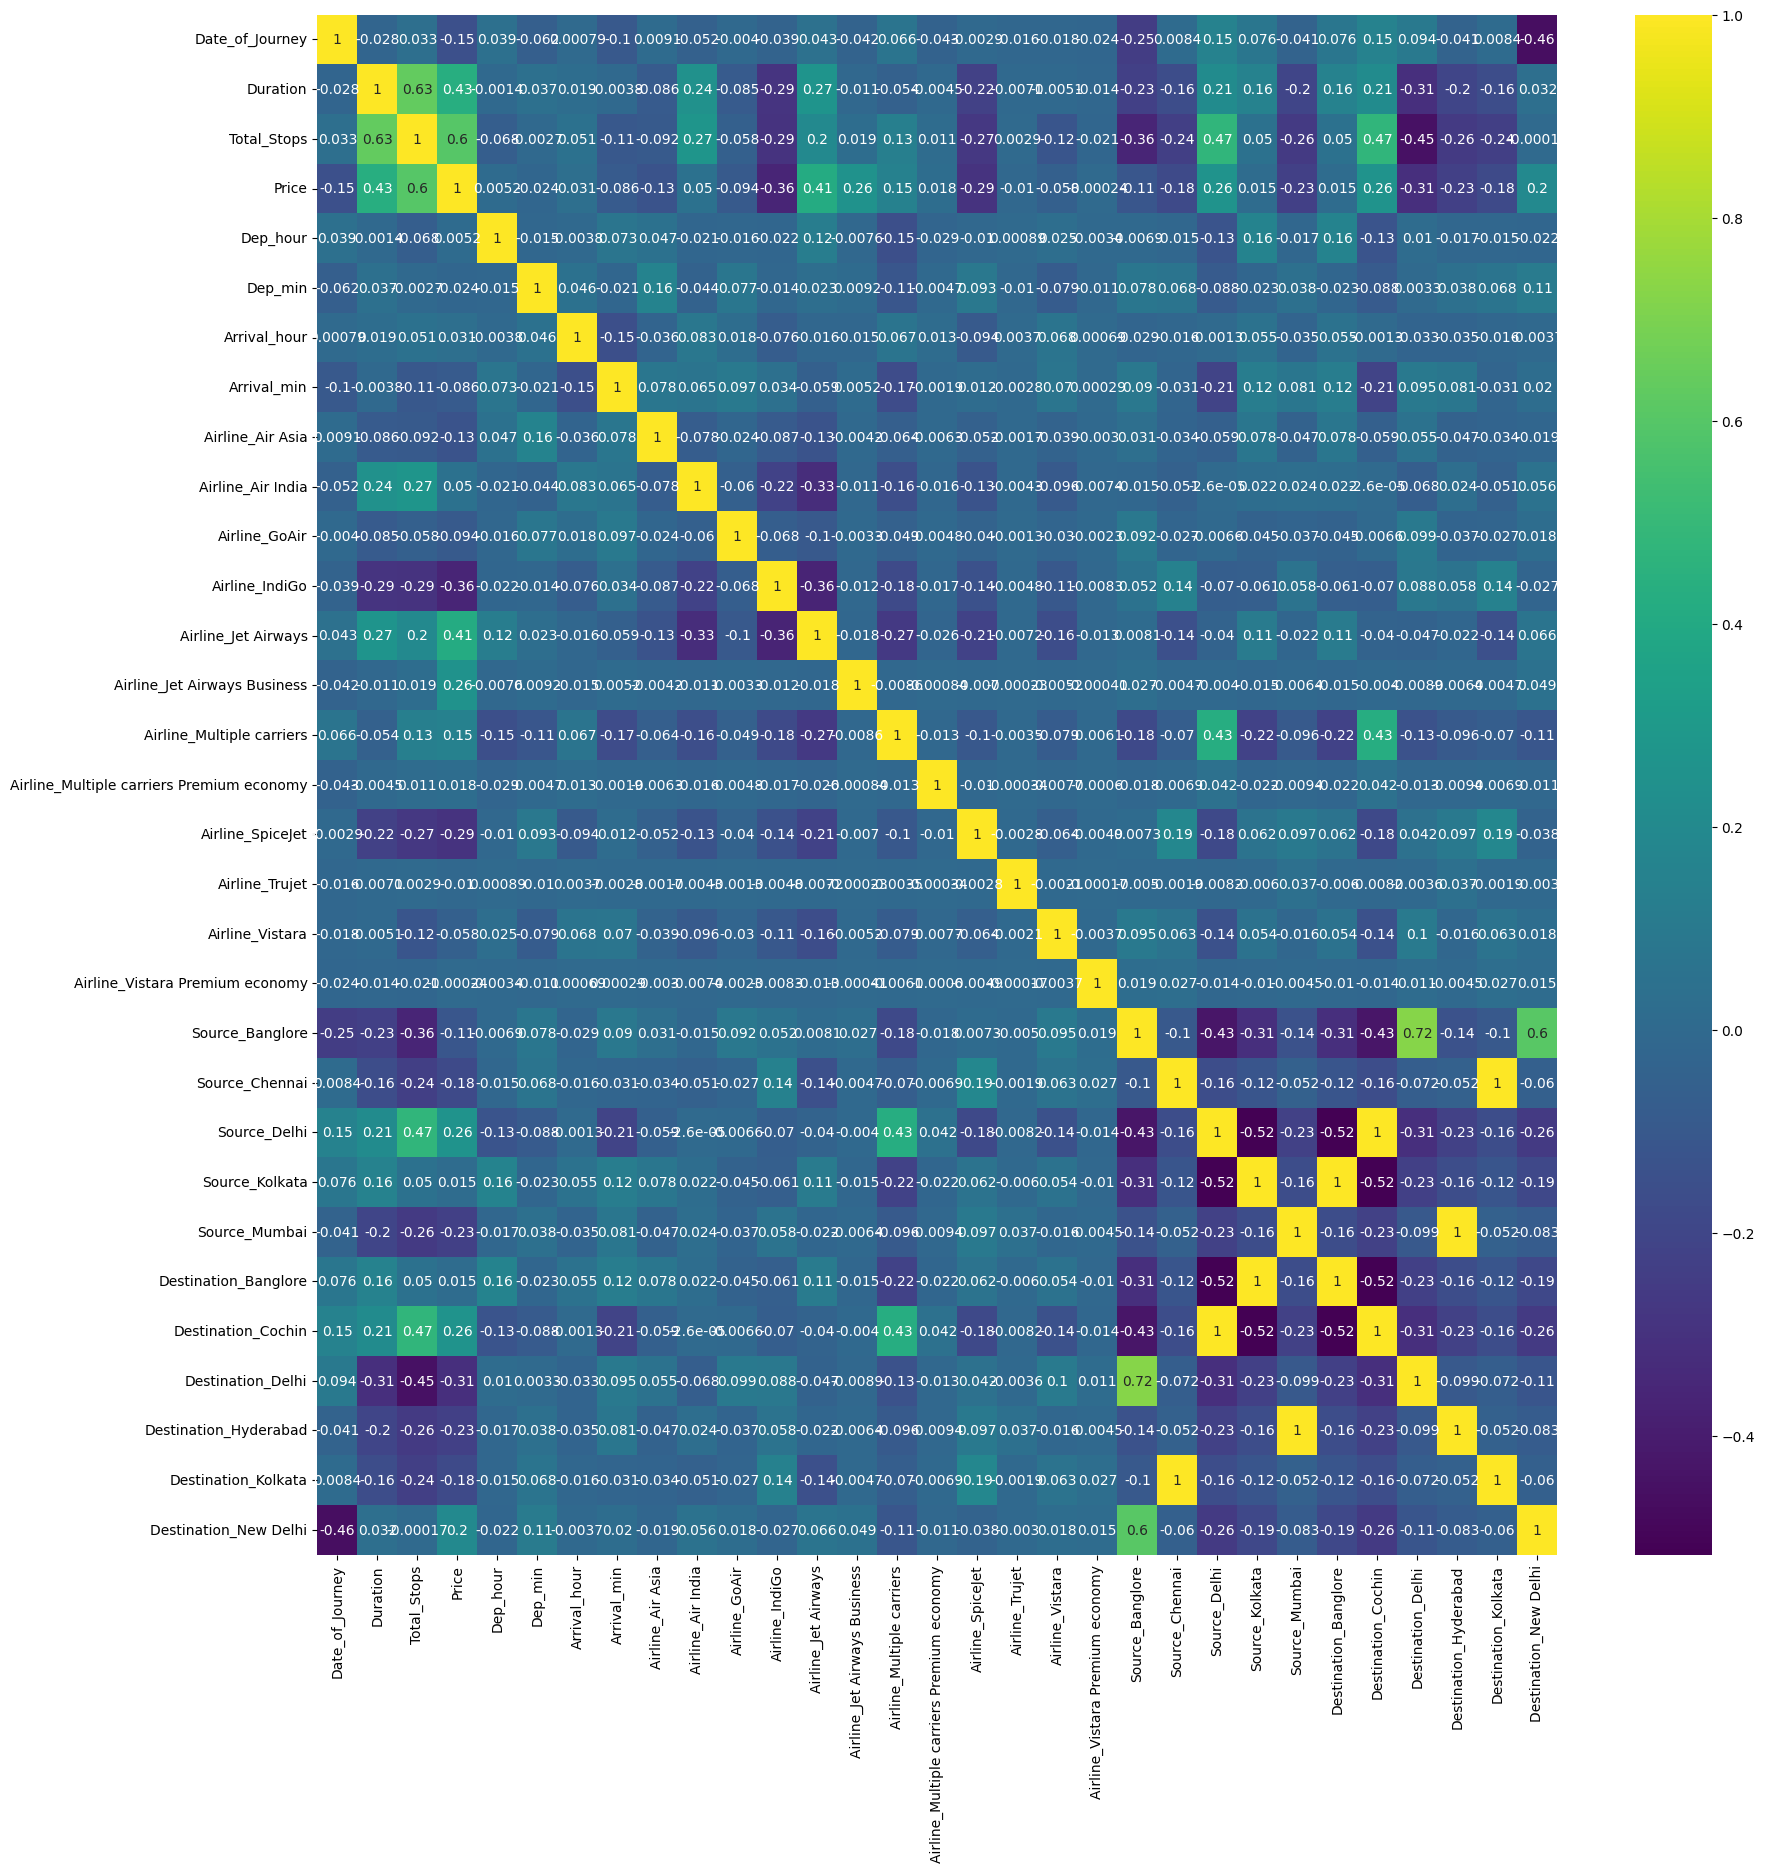

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),cmap='viridis',annot=True)
plt.show()



The data shows that** Price** is most strongly **influenced by Total_Stops** (0.60 correlation) and **Duration** (0.43 correlation), with 1-stop flights containing the most expensive outliers peaking at 80,000.

### ML

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)#removing target column in input
y = df['Price']#output-target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,#20% data → testing,80% data → training
    random_state=42 #Ensures same split every time you run
)

In [24]:
import pickle #saving my data using pickle(train test df)

with open('flight_df.pkl', 'wb') as f:
    pickle.dump(df, f)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": xgb.XGBRegressor()
}

In [26]:
df


,Date_of_Journey,Duration,Total_Stops,Price,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Airline_Air Asia,Airline_Air India,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,2019-03-24,170,0.0,3897,22,20,1,10,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2019-05-01,445,2.0,7662,5,50,13,15,False,True,...,False,False,True,False,True,False,False,False,False,False
2,2019-06-09,19,2.0,13882,9,25,4,25,False,False,...,False,True,False,False,False,True,False,False,False,False
3,2019-05-12,325,1.0,6218,18,5,23,30,False,False,...,False,False,True,False,True,False,False,False,False,False
4,2019-03-01,285,1.0,13302,16,50,21,35,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,2019-04-09,150,0.0,4107,19,55,22,25,True,False,...,False,False,True,False,True,False,False,False,False,False
10679,2019-04-27,155,0.0,4145,20,45,23,20,False,True,...,False,False,True,False,True,False,False,False,False,False
10680,2019-04-27,3,0.0,7229,8,20,11,20,False,False,...,False,False,False,False,False,False,True,False,False,False
10681,2019-03-01,160,0.0,12648,11,30,14,10,False,False,...,False,False,False,False,False,False,False,False,False,True


In [27]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)# changing boolean to int

In [28]:
df['Journey_day'] = df['Date_of_Journey'].dt.day
df['Journey_month'] = df['Date_of_Journey'].dt.month
df['Journey_year'] = df['Date_of_Journey'].dt.year#spliting day month and year from date

In [29]:
df.drop('Date_of_Journey', axis=1, inplace=True)#dropping orginal column

In [30]:
df['Total_Stops'] = df['Total_Stops'].fillna(0).astype(int)#shows float so changed to int

In [31]:
df

,Duration,Total_Stops,Price,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Airline_Air Asia,Airline_Air India,Airline_GoAir,...,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Journey_day,Journey_month,Journey_year
0,170,0,3897,22,20,1,10,0,0,0,...,0,0,0,0,0,0,1,24,3,2019
1,445,2,7662,5,50,13,15,0,1,0,...,0,1,0,0,0,0,0,1,5,2019
2,19,2,13882,9,25,4,25,0,0,0,...,0,0,1,0,0,0,0,9,6,2019
3,325,1,6218,18,5,23,30,0,0,0,...,0,1,0,0,0,0,0,12,5,2019
4,285,1,13302,16,50,21,35,0,0,0,...,0,0,0,0,0,0,1,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,150,0,4107,19,55,22,25,1,0,0,...,0,1,0,0,0,0,0,9,4,2019
10679,155,0,4145,20,45,23,20,0,1,0,...,0,1,0,0,0,0,0,27,4,2019
10680,3,0,7229,8,20,11,20,0,0,0,...,0,0,0,1,0,0,0,27,4,2019
10681,160,0,12648,11,30,14,10,0,0,0,...,0,0,0,0,0,0,1,1,3,2019


### 1.linear regression

In [32]:
lr=LinearRegression()

In [33]:
x = df.drop('Price', axis=1)
y = df['Price']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [35]:
lr.fit(x_train,y_train)#fiting trainning data to ml

LinearRegression()

In [36]:
y_pred = lr.predict(x_test)#predicts values using unseen test data & stored in y

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mean_absolute_error(y_test,y_pred)

1958.0843704811798

In [ ]:
score = r2_score(y_test, y_pred)
score

0.6020193873786335

### 2.RandomForestRegressor

In [ ]:
rfr=RandomForestRegressor()

In [ ]:
rfr.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
 y_pred = rfr.predict(x_test)

In [ ]:
mean_absolute_error(y_test,y_pred)

1211.101633125448

In [ ]:
score = r2_score(y_test, y_pred)
score

0.8082576450612005

### 3.XGBoost

In [41]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

In [42]:
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [43]:
y_pred = xgb.predict(x_test)

In [46]:
score = r2_score(y_test, y_pred)
score

0.8366833925247192

In [48]:
# Save model
with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb, file)

print("Model saved successfully!")

Model saved successfully!


xgboost is best out of 3 algorithm

**Project** Conclusion

The objective of this **project was to predict flight ticket prices** based on various features such as airline, journey date, duration, and number of stops.
**bold text**
**Data preprocessing **was performed by **handling missing values, converting date and time columns into numerical features, and encoding categorical variables**. All features were transformed into a suitable numerical format for machine learning models.

M**ultiple regression models** including Linear Regression, Random Forest, and XGBoost were trained and evaluated using performance metrics such as Mean Absolute Error (MAE) and R² score.

Among all models, **XGBoost performed the best with the lowest MAE (~1157) and highest R² score,** indicating better prediction accuracy compared to other models. Random Forest also showed good performance, while Linear Regression had comparatively lower accuracy.

Therefore, **XGBoost was selected as the final model for predicting flight prices due to its superior performance and ability to handle complex relationships in the data.**

This model can be further **improved using hyperparameter tuning **and deployed in real-world applications for price prediction.